In [439]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

df=pd.read_csv("dataset.csv")
df.head()


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Exploratory Data Analysis (EDA) and Data Cleaning

In [440]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [441]:
df=df.dropna()
df.isna().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [442]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,56999.421925,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,32909.243463,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.500000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,56999.000000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.500000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [443]:
# drop columns not needed
df= df.drop(columns=['Unnamed: 0','key','mode','time_signature','duration_ms','liveness'])
df.head()

,track_id,artists,album_name,track_name,popularity,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,tempo,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,False,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.715,87.917,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,False,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.267,77.489,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,False,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.120,76.332,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,False,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.143,181.740,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,False,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.167,119.949,acoustic


In [444]:
#remove duplicates
duplicates= df.duplicated()
print(f"num of duplicated data: {duplicates.sum()}")
df = df.drop_duplicates()

num of duplicated data: 450


In [445]:
# remove less popular songs
print(f"Songs with popularity = 0  : {(df['popularity'] == 0).sum():,}")
print(f"Songs with popularity < 10 : {(df['popularity'] < 10).sum():,}")

df = df[df['popularity'] >= 10].copy()

Songs with popularity = 0  : 15,843
Songs with popularity < 10 : 22,457


In [446]:
features= ['danceability','energy','loudness','speechiness','acousticness','instrumentalness','valence','tempo']

print("Feature ranges")
df[features].describe().loc[["min","max","mean"]]
#tempo needs to be scaled along with loudness

Feature ranges


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,tempo
min,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.0000
max,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,0.995000,243.3720
mean,0.561558,0.646013,-8.238738,0.086563,0.314604,0.159318,0.466177,122.7631


In [447]:
# Final cleaned dataset summary
print("DATASET SUMMARY")
print(f"Total songs  : {len(df):,}")
print(f"Columns      : {df.shape[1]}")
print(f"Missing vals : {df.isnull().sum().sum()}")
print(f"Duplicates   : {df.duplicated().sum()}")


DATASET SUMMARY
Total songs  : 91,092
Columns      : 15
Missing vals : 0
Duplicates   : 0


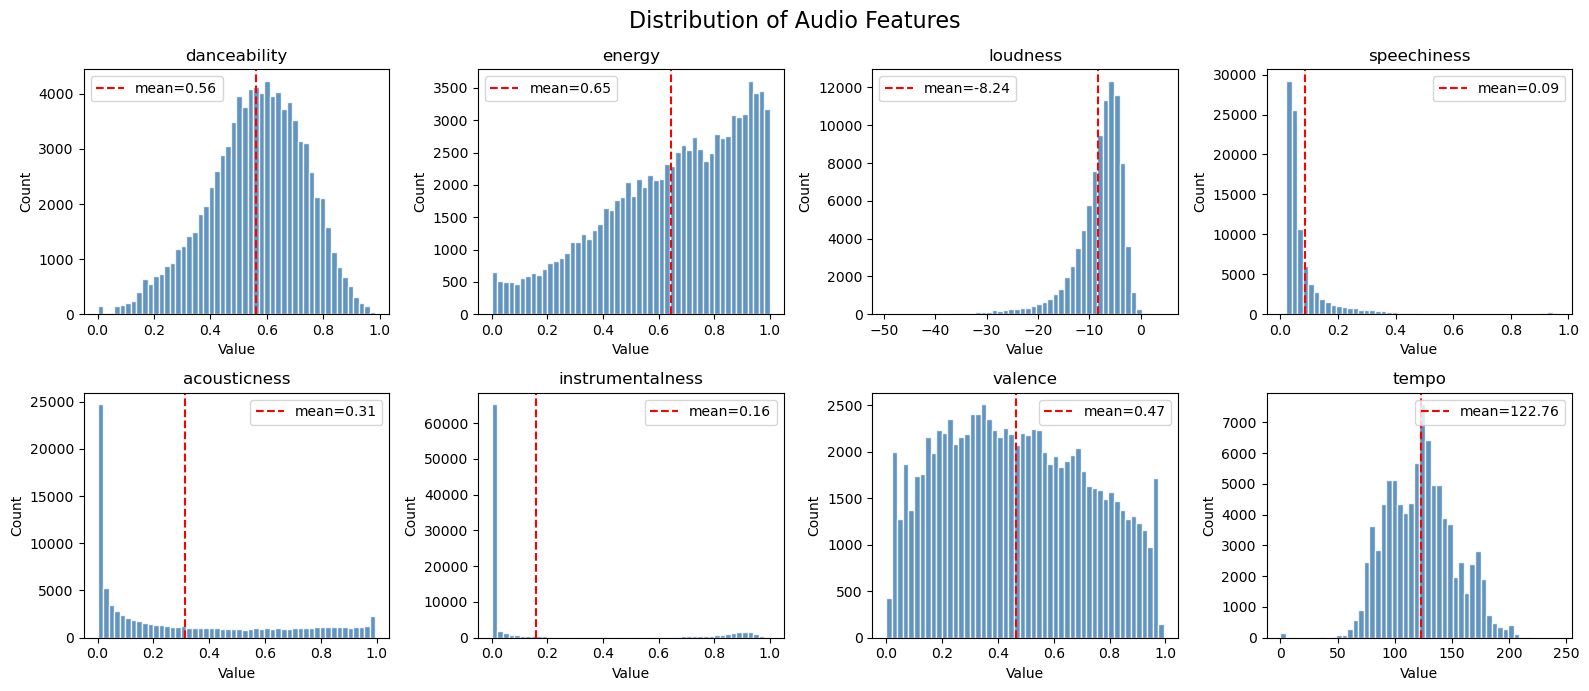

In [448]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Distribution of Audio Features',fontsize=16)

for ax, feat in zip(axes.flatten(), features):
    ax.hist(df[feat], bins=50, color='steelblue', edgecolor='white',alpha=0.85)
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    mean_val = df[feat].mean()
    ax.axvline(mean_val, color='red', linestyle='--',
               label=f'mean={mean_val:.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

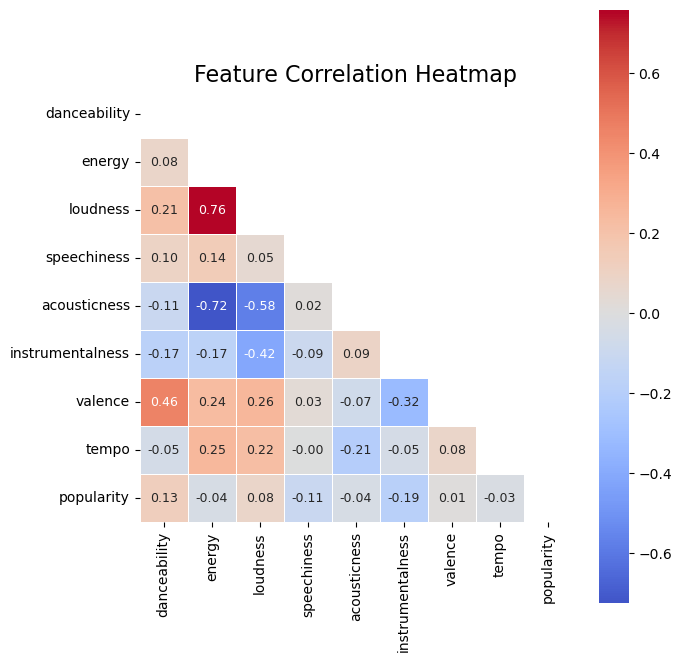

In [449]:
fig, ax = plt.subplots(figsize=(7, 7))
corr = df[features + ['popularity']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

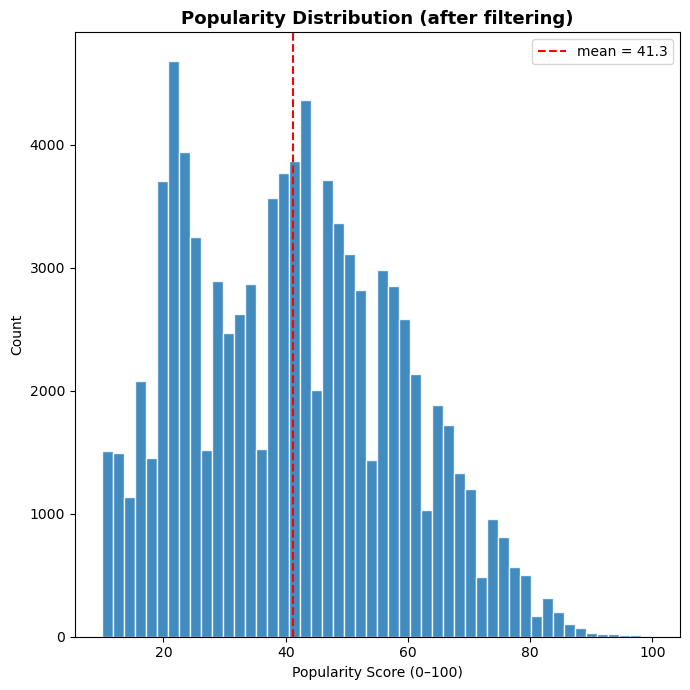

In [450]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.hist(df['popularity'], bins=50,edgecolor='white', alpha=0.85)
ax.axvline(df['popularity'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"mean = {df['popularity'].mean():.1f}")
ax.set_title('Popularity Distribution (after filtering)', fontsize=13, fontweight='bold')
ax.set_xlabel('Popularity Score (0–100)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

In [451]:
# Assign mood Russel Circumplex model
def assign_mood(row):
    v=row['valence']
    e=row['energy']
    d=row['danceability']
    a=row['acousticness']

    # High valence + High energy
    if v >= 0.5 and e >= 0.5:
        if d >= 0.7:
            return 'Energetic'
        else:
            return 'Happy'

    # Low valence + High energy
    elif v < 0.5 and e >= 0.5:
        return 'Angry'

    # High valence + Low energy
    elif v >= 0.5 and e < 0.5:
        if a >= 0.5:
            return 'Romantic'
        else:
            return 'Calm'

    # Low valence + Low energy
    else:
        if a >= 0.6:
            return 'Low Energy'
        else:
            return 'Sad'

df['mood'] = df.apply(assign_mood, axis=1)
print(df['mood'].value_counts())
df.head(50)

mood
Angry         32284
Happy         22430
Low Energy    12399
Energetic     11033
Sad            6085
Romantic       4631
Calm           2230
Name: count, dtype: int64


,track_id,artists,album_name,track_name,popularity,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,tempo,track_genre,mood
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,False,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.7150,87.917,acoustic,Calm
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,False,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.2670,77.489,acoustic,Low Energy
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,False,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1200,76.332,acoustic,Sad
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,False,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1430,181.740,acoustic,Low Energy
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,False,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.1670,119.949,acoustic,Sad
5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,False,0.688,0.4810,-8.807,0.1050,0.2890,0.000000,0.6660,98.017,acoustic,Calm
6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,False,0.407,0.1470,-8.822,0.0355,0.8570,0.000003,0.0765,141.284,acoustic,Low Energy
7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,False,0.703,0.4440,-9.331,0.0417,0.5590,0.000000,0.7120,150.960,acoustic,Romantic
8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,False,0.625,0.4140,-8.700,0.0369,0.2940,0.000000,0.6690,130.088,acoustic,Calm
9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,False,0.442,0.6320,-6.770,0.0295,0.4260,0.004190,0.1960,78.899,acoustic,Angry


In [452]:
#Correlation between mood and features
from scipy import stats

print("ANOVA — Feature vs Mood")
print(f"{'Feature':<22} {'F-statistic':>12}  {'p-value':>12}  {'Result'}")
print("-" * 65)

anova_results = {}
for feat in features:
    groups = [df[df['mood'] == m][feat].values for m in ['Energetic','Happy','Romantic','Calm','Angry','Low Energy','Sad']]
    f_stat, p_val = stats.f_oneway(*groups)
    significance = "useful" if p_val < 0.05 else "not useful"
    anova_results[feat] = {'f_stat': f_stat, 'p_val': p_val}
    print(f"{feat:<22} {f_stat:>12.2f}  {p_val:>12.2e}  {significance}")

ANOVA — Feature vs Mood
Feature                 F-statistic       p-value  Result
-----------------------------------------------------------------
danceability                6427.38      0.00e+00  useful


energy                     36351.56      0.00e+00  useful
loudness                   11473.17      0.00e+00  useful
speechiness                  314.48      0.00e+00  useful
acousticness               21847.08      0.00e+00  useful
instrumentalness            1265.16      0.00e+00  useful
valence                    41509.00      0.00e+00  useful
tempo                        746.46      0.00e+00  useful


In [453]:
# Mean feature value per mood
mood_means = df.groupby('mood')[features].mean()

print("Mean feature value per mood:")
print(mood_means.to_string())

Mean feature value per mood:
            danceability    energy   loudness  speechiness  acousticness  instrumentalness   valence       tempo
mood                                                                                                            
Angry           0.519626  0.778767  -6.359844     0.097769      0.140921          0.188297  0.285456  126.536528
Calm            0.701242  0.418959 -10.814610     0.099639      0.236941          0.101860  0.687980  119.187174
Energetic       0.777740  0.736789  -6.396449     0.102430      0.223245          0.077477  0.753216  119.079330
Happy           0.557646  0.786682  -6.255316     0.085528      0.228480          0.066907  0.703221  129.290234
Low Energy      0.450196  0.244353 -15.221653     0.053918      0.853480          0.330185  0.239168  110.787271
Romantic        0.620033  0.347273 -11.782718     0.084844      0.779952          0.119615  0.675234  117.062154
Sad             0.537710  0.387575 -10.988915     0.065187      0.2

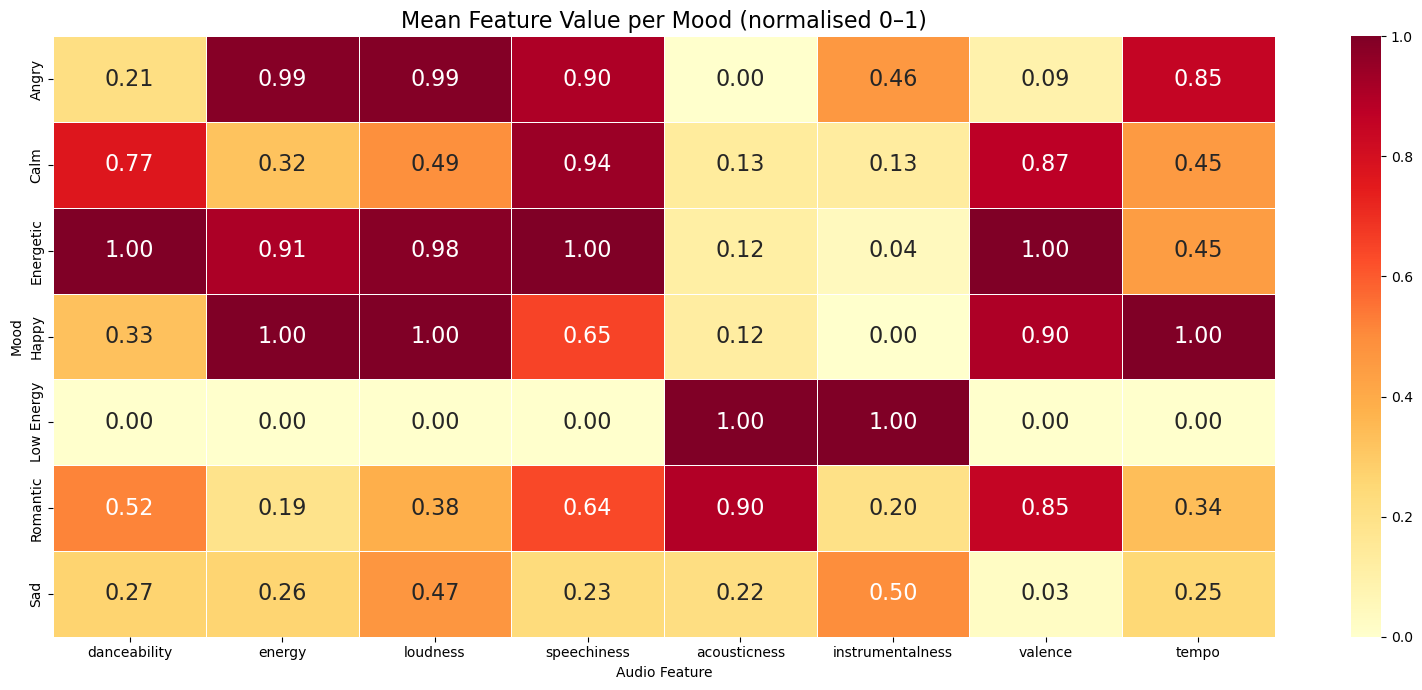

In [454]:
# Normalise means to 0-1 range so all features are comparable in the heatmap
mood_means_norm = (mood_means - mood_means.min()) / (mood_means.max() - mood_means.min())

fig, ax = plt.subplots(figsize=(16,7))

# Normalised heatmap
sns.heatmap(mood_means_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5,ax=ax,annot_kws={'size':16})

ax.set_title('Mean Feature Value per Mood (normalised 0–1)',fontsize=16)
ax.set_xlabel('Audio Feature')
ax.set_ylabel('Mood')

plt.tight_layout()
plt.show()


Preprocessing

In [455]:
#Select Features and lables

X= df[features]
y= df['mood']

In [456]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [457]:
#scale all features including loudness and tempo for KNN
scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

RANDOM FOREST CLASSIFICATION FOR MOOD

In [458]:
# Use Random forest for mood prediction
rfc= RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rfc.fit(x_train,y_train)
y_pred_rfc= rfc.predict(x_test)

print("Random forest results")
print("-"*42)
print(classification_report(y_test,y_pred_rfc))
# all 1 because the mood was assigned based on valence and energy

Random forest results
------------------------------------------
              precision    recall  f1-score   support

       Angry       1.00      1.00      1.00      9685
        Calm       1.00      1.00      1.00       669
   Energetic       1.00      1.00      1.00      3310
       Happy       1.00      1.00      1.00      6729
  Low Energy       1.00      1.00      1.00      3720
    Romantic       1.00      1.00      1.00      1389
         Sad       1.00      1.00      1.00      1826

    accuracy                           1.00     27328
   macro avg       1.00      1.00      1.00     27328
weighted avg       1.00      1.00      1.00     27328



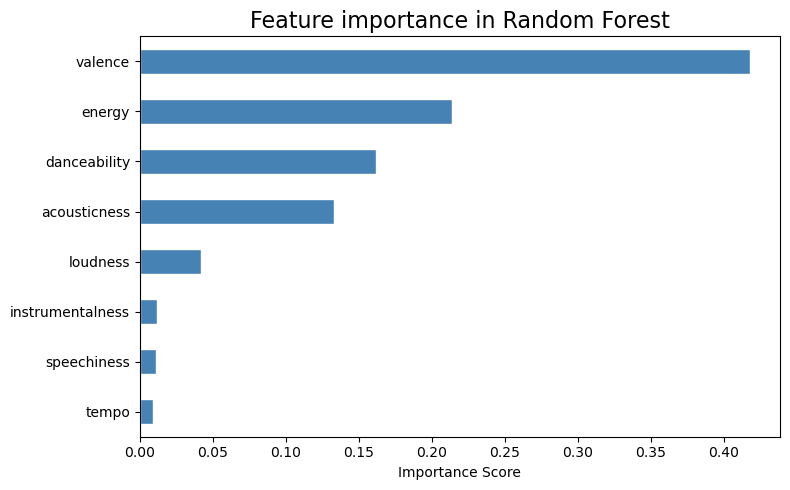

In [459]:
# Feature importance
importances = pd.Series(rfc.feature_importances_,
                         index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Feature importance in Random Forest',fontsize=16)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()


K-NEAREST NEIGHBORS (KNN) TO BE ABLE TO RECOMMEND NEW SONGS

In [460]:
knn= KNeighborsClassifier(n_neighbors=5,metric='euclidean')
knn.fit(x_train_scaled,y_train)

y_pred_knn= knn.predict(x_test_scaled)
print("KNN Results")
print("-"*42)
print(classification_report(y_test,y_pred_knn))

KNN Results
------------------------------------------
              precision    recall  f1-score   support

       Angry       0.94      0.95      0.94      9685
        Calm       0.79      0.76      0.77       669
   Energetic       0.91      0.91      0.91      3310
       Happy       0.92      0.92      0.92      6729
  Low Energy       0.93      0.96      0.94      3720
    Romantic       0.89      0.85      0.87      1389
         Sad       0.88      0.81      0.84      1826

    accuracy                           0.92     27328
   macro avg       0.89      0.88      0.89     27328
weighted avg       0.92      0.92      0.92     27328

